<a href="https://colab.research.google.com/github/ojaswip2828/Data_science/blob/main/Data_Loading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pandas: Reading CSV Files

CSV stands for **Comma-Separated Values**.

A CSV file is a simple text file used to store tabular data.

Each row represents a record and each column represents a feature or field.

Example:

Name,Age,City
Alice,21,Bangalore
Bob,22,Mumbai
Charlie,20,Delhi

Pandas provides the `read_csv()` function to load CSV data into a DataFrame.

## 1. Importing Pandas

Before working with CSV files, we need to import the Pandas library.

We usually import Pandas using the alias `pd`.

In [1]:
import pandas as pd

## 2. Reading a CSV File

The `pd.read_csv()` function is used to read a CSV file and convert it into a Pandas DataFrame.

### Syntax

```python
pd.read_csv("file_path")


### Code cell

```python
df = pd.read_csv("people.csv")

df

## 3. Creating a Sample CSV Dataset

For learning purposes, we can create our own CSV file using Python.

In [2]:
data = """Name,Age,City,Salary,Join_Date
Alice,21,Bangalore,45000,2024-01-10
Bob,22,Mumbai,50000,2023-06-15
Charlie,23,Delhi,55000,2022-09-20
David,21,Chennai,48000,2024-02-12
Eva,24,Pune,60000,2021-11-05
"""

with open("employees.csv", "w") as file:
    file.write(data)

In [3]:
df = pd.read_csv("employees.csv")

df

,Name,Age,City,Salary,Join_Date
0,Alice,21,Bangalore,45000,2024-01-10
1,Bob,22,Mumbai,50000,2023-06-15
2,Charlie,23,Delhi,55000,2022-09-20
3,David,21,Chennai,48000,2024-02-12
4,Eva,24,Pune,60000,2021-11-05


## 4. Understanding the Loaded Data

After loading a CSV file, the data is stored as a Pandas DataFrame.

A DataFrame is a two-dimensional table containing rows and columns.

We can use several functions to understand the dataset.

In [4]:
df.head()

,Name,Age,City,Salary,Join_Date
0,Alice,21,Bangalore,45000,2024-01-10
1,Bob,22,Mumbai,50000,2023-06-15
2,Charlie,23,Delhi,55000,2022-09-20
3,David,21,Chennai,48000,2024-02-12
4,Eva,24,Pune,60000,2021-11-05


In [5]:
df.tail()

,Name,Age,City,Salary,Join_Date
0,Alice,21,Bangalore,45000,2024-01-10
1,Bob,22,Mumbai,50000,2023-06-15
2,Charlie,23,Delhi,55000,2022-09-20
3,David,21,Chennai,48000,2024-02-12
4,Eva,24,Pune,60000,2021-11-05


In [6]:
df.shape

(5, 5)

In [7]:
df.columns

Index(['Name', 'Age', 'City', 'Salary', 'Join_Date'], dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Name       5 non-null      object
 1   Age        5 non-null      int64 
 2   City       5 non-null      object
 3   Salary     5 non-null      int64 
 4   Join_Date  5 non-null      object
dtypes: int64(2), object(3)
memory usage: 332.0+ bytes


In [9]:
df.describe()

,Age,Salary
count,5.00000,5.000000
mean,22.20000,51600.000000
std,1.30384,5941.380311
min,21.00000,45000.000000
25%,21.00000,48000.000000
50%,22.00000,50000.000000
75%,23.00000,55000.000000
max,24.00000,60000.000000


## 5. Loading Specific Columns

The `usecols` parameter allows us to load only selected columns from a CSV file.

This can be useful when we don't need the entire dataset.

It can also reduce memory usage when working with large datasets.

In [10]:
df = pd.read_csv(
    "employees.csv",
    usecols=["Name", "Salary"]
)

df

,Name,Salary
0,Alice,45000
1,Bob,50000
2,Charlie,55000
3,David,48000
4,Eva,60000


## 6. Setting an Index Column

By default, Pandas creates a numerical index:

0, 1, 2, 3, ...

We can use `index_col` to make an existing column the DataFrame index.

In [11]:
df = pd.read_csv(
    "employees.csv",
    index_col="Name"
)

df

,Age,City,Salary,Join_Date
Name,,,,
Alice,21,Bangalore,45000,2024-01-10
Bob,22,Mumbai,50000,2023-06-15
Charlie,23,Delhi,55000,2022-09-20
David,21,Chennai,48000,2024-02-12
Eva,24,Pune,60000,2021-11-05


## 7. Reading Only a Specific Number of Rows

The `nrows` parameter tells Pandas to read only a specified number of rows from the CSV file.

This can be useful when testing a large dataset.

In [12]:
df = pd.read_csv(
    "employees.csv",
    nrows=3
)

df
#→ reads only 3 rows.

,Name,Age,City,Salary,Join_Date
0,Alice,21,Bangalore,45000,2024-01-10
1,Bob,22,Mumbai,50000,2023-06-15
2,Charlie,23,Delhi,55000,2022-09-20


In [13]:
df = pd.read_csv("employees.csv")
df.head(3)
#→ reads the dataset, then displays 3 rows.

,Name,Age,City,Salary,Join_Date
0,Alice,21,Bangalore,45000,2024-01-10
1,Bob,22,Mumbai,50000,2023-06-15
2,Charlie,23,Delhi,55000,2022-09-20


## 8. Skipping Rows

The `skiprows` parameter allows us to skip specific rows while reading a CSV file.

This is useful when a file contains unwanted rows, metadata, or extra information before the actual dataset.

In [14]:
df = pd.read_csv(
    "employees.csv",
    skiprows=[1]
)

df

,Name,Age,City,Salary,Join_Date
0,Bob,22,Mumbai,50000,2023-06-15
1,Charlie,23,Delhi,55000,2022-09-20
2,David,21,Chennai,48000,2024-02-12
3,Eva,24,Pune,60000,2021-11-05


## 9. Handling Missing Values While Loading

Real-world datasets may represent missing values using different strings such as:

- N/A
- NA
- Unknown
- Missing
- -

The `na_values` parameter tells Pandas which values should be treated as missing (`NaN`).

In [15]:
data = """Name,Age,City
Alice,21,Bangalore
Bob,N/A,Mumbai
Charlie,Unknown,Delhi
David,23,Pune
"""

with open("missing_data.csv", "w") as file:
    file.write(data)

In [16]:
df = pd.read_csv(
    "missing_data.csv",
    na_values=["N/A", "Unknown"]
)

df

,Name,Age,City
0,Alice,21.0,Bangalore
1,Bob,NaN,Mumbai
2,Charlie,NaN,Delhi
3,David,23.0,Pune


In [17]:
df.isna()

,Name,Age,City
0,False,False,False
1,False,True,False
2,False,True,False
3,False,False,False


In [18]:
df.isna()

,Name,Age,City
0,False,False,False
1,False,True,False
2,False,True,False
3,False,False,False


Different Delimiters

This is worth learning, but don't spend too much time on the complicated regex example from the article yet.

## 10. Reading Files with Different Delimiters

Although CSV usually uses commas, some files use other delimiters.

Examples:

Comma:
`,`

Semicolon:
`;`

Tab:
`\t`

Pipe:
`|`

In [19]:
data = """Name;Age;City
Alice;21;Bangalore
Bob;22;Mumbai
Charlie;23;Delhi
"""

with open("semicolon_data.csv", "w") as file:
    file.write(data)

In [20]:
df = pd.read_csv(
    "semicolon_data.csv",
    sep=";"
)

df

,Name,Age,City
0,Alice,21,Bangalore
1,Bob,22,Mumbai
2,Charlie,23,Delhi


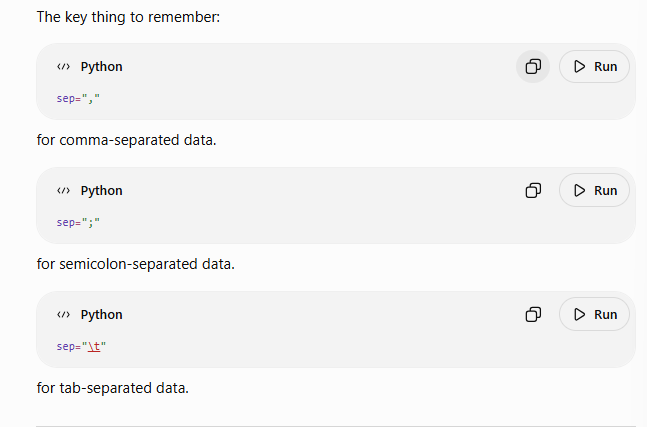

Regex Separator

The article's complicated example is teaching something slightly more advanced.

You can encounter files where multiple characters act as delimiters.

In [21]:
# df = pd.read_csv(
#     "sample.csv",
#     sep=r"[:,|_]",
#     engine="python"
# )
# #r"[:,|_]"

engine="python"

is used because regex separators require the Python parsing engine in cases where the default parser cannot handle them.

For your current learning level, understand the concept rather than memorizing this syntax.

parse_dates

## 11. Parsing Dates

CSV files store data as text.

A date may initially be read as a string.

The `parse_dates` parameter can be used to convert date columns into datetime values while reading the file.

In [22]:
df = pd.read_csv(
    "employees.csv",
    parse_dates=["Join_Date"]
)

df

,Name,Age,City,Salary,Join_Date
0,Alice,21,Bangalore,45000,2024-01-10
1,Bob,22,Mumbai,50000,2023-06-15
2,Charlie,23,Delhi,55000,2022-09-20
3,David,21,Chennai,48000,2024-02-12
4,Eva,24,Pune,60000,2021-11-05


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Name       5 non-null      object        
 1   Age        5 non-null      int64         
 2   City       5 non-null      object        
 3   Salary     5 non-null      int64         
 4   Join_Date  5 non-null      datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 332.0+ bytes


In [24]:
df["Join_Date"].dt.year

,Join_Date
0,2024
1,2023
2,2022
3,2024
4,2021


In [25]:
df["Join_Date"].dt.month

,Join_Date
0,1
1,6
2,9
3,2
4,11


Reading CSV from a URL

## 12. Reading a CSV File from a URL

Pandas can directly read a CSV file from an internet URL.

This is useful when datasets are hosted online, for example on GitHub or other public websites.

In [26]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"

df = pd.read_csv(url)

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [27]:
df.shape

(150, 5)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [29]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


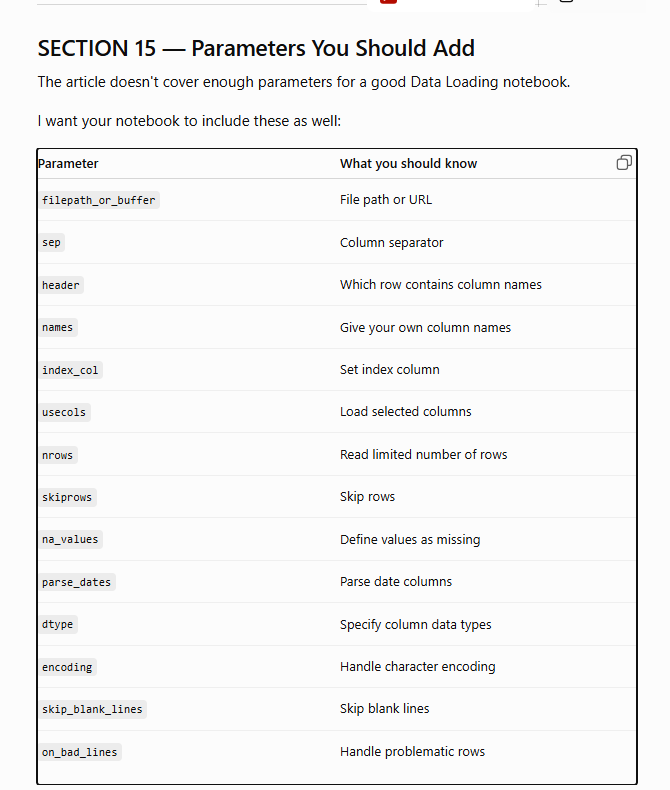

## 13. Specifying Data Types

The `dtype` parameter allows us to explicitly specify the data type of a column while loading the CSV.

In [30]:
df = pd.read_csv(
    "employees.csv",
    dtype={
        "Age": "int64",
        "Salary": "float64"
    }
)

## 14. Encoding

Sometimes a CSV file contains special characters or characters from different languages.

If Pandas cannot decode the file correctly, we may need to specify the encoding.

Example:

```python
df = pd.read_csv(
    "data.csv",
    encoding="utf-8"
)


You don't need to experiment heavily with this now. Just understand **why `encoding` exists**.

---

# SECTION 18 — Common Errors

I definitely want this in your Colab because it makes the notebook much more useful.

### Markdown cell

```markdown
# Common Errors While Reading CSV Files

## 1. FileNotFoundError

This usually means Pandas cannot find the specified file.

Example:

```python
pd.read_csv("wrong_file.csv")

ParserError

This can happen when the structure of the CSV is inconsistent.

Possible solutions include:

Check the delimiter
Check malformed rows
Use sep
Investigate problematic rows
Use on_bad_lines when appropriate

Wrong Number of Columns

If the file uses ; instead of ,, using:

pd.read_csv("data.csv")

may load the entire row incorrectly.


---

# SECTION 19 — The Big Picture

Put this toward the end of your notebook:

```markdown
# CSV Loading — Big Picture

The general workflow is:

CSV File
   ↓
pd.read_csv()
   ↓
DataFrame
   ↓
Inspect the Data
   ↓
Clean the Data
   ↓
Analyze the Data

Important `read_csv()` parameters:

- `sep` → delimiter
- `header` → header row
- `names` → custom column names
- `usecols` → selected columns
- `index_col` → index column
- `nrows` → number of rows to read
- `skiprows` → rows to skip
- `na_values` → values treated as missing
- `parse_dates` → convert dates
- `dtype` → specify data types
- `encoding` → character encoding

# Pandas: Reading Excel Files

Excel is a commonly used format for storing structured tabular data.

Excel files can contain:

- Rows and columns
- Multiple worksheets (sheets)
- Different data types
- Missing values
- Dates
- Formulas

Pandas provides the `read_excel()` function to load Excel data into a Pandas DataFrame.

The general workflow is:

Excel File
   ↓
pd.read_excel()
   ↓
DataFrame
   ↓
Data Inspection
   ↓
Data Cleaning
   ↓
Data Analysis

## 1. Installing the Required Library

Pandas uses an Excel engine to read Excel files.

For modern `.xlsx` files, `openpyxl` is commonly used.

In [31]:
!pip install openpyxl

In [32]:
import pandas as pd

## 2. Reading an Excel File

The `pd.read_excel()` function is used to read an Excel file into a Pandas DataFrame.

### Syntax

```python
pd.read_excel("file_path")


### Code cell

```python
df = pd.read_excel("sample.xlsx")

df

Excel File
    ↓
pd.read_excel()
    ↓
DataFrame

## 3. Creating a Sample Excel Workbook

We can create an Excel workbook containing multiple sheets.

This will help us understand how `sheet_name` works.

In [33]:
data = {
    "Name": ["Alice", "Bob", "Charlie", "David", "Eva"],
    "Age": [21, 22, 23, 21, 24],
    "City": ["Bangalore", "Mumbai", "Delhi", "Chennai", "Pune"],
    "Salary": [45000, 50000, 55000, 48000, 60000],
    "Join_Date": [
        "2024-01-10",
        "2023-06-15",
        "2022-09-20",
        "2024-02-12",
        "2021-11-05"
    ]
}

employees = pd.DataFrame(data)

employees

,Name,Age,City,Salary,Join_Date
0,Alice,21,Bangalore,45000,2024-01-10
1,Bob,22,Mumbai,50000,2023-06-15
2,Charlie,23,Delhi,55000,2022-09-20
3,David,21,Chennai,48000,2024-02-12
4,Eva,24,Pune,60000,2021-11-05


In [34]:
with pd.ExcelWriter("employees.xlsx") as writer:
    employees.to_excel(
        writer,
        sheet_name="Employees",
        index=False
    )

In [35]:
df = pd.read_excel("employees.xlsx")

df

,Name,Age,City,Salary,Join_Date
0,Alice,21,Bangalore,45000,2024-01-10
1,Bob,22,Mumbai,50000,2023-06-15
2,Charlie,23,Delhi,55000,2022-09-20
3,David,21,Chennai,48000,2024-02-12
4,Eva,24,Pune,60000,2021-11-05


## 4. Reading a Specific Sheet

The `sheet_name` parameter allows us to specify which worksheet should be loaded.

In [36]:
df = pd.read_excel(
    "employees.xlsx",
    sheet_name="Employees"
)

df

,Name,Age,City,Salary,Join_Date
0,Alice,21,Bangalore,45000,2024-01-10
1,Bob,22,Mumbai,50000,2023-06-15
2,Charlie,23,Delhi,55000,2022-09-20
3,David,21,Chennai,48000,2024-02-12
4,Eva,24,Pune,60000,2021-11-05


In [37]:
df = pd.read_excel(
    "employees.xlsx",
    sheet_name=0
)


## 5. Reading Multiple Sheets

We can load multiple worksheets from an Excel workbook.

When multiple sheets are requested, Pandas returns a dictionary of DataFrames.

In [38]:
data = {
    "Name": ["Alice", "Bob", "Charlie"],
    "Department": ["IT", "HR", "Finance"]
}

departments = pd.DataFrame(data)

with pd.ExcelWriter("company.xlsx") as writer:
    employees.to_excel(
        writer,
        sheet_name="Employees",
        index=False
    )

    departments.to_excel(
        writer,
        sheet_name="Departments",
        index=False
    )

In [39]:
all_sheets = pd.read_excel(
    "company.xlsx",
    sheet_name=None
)

all_sheets

{'Employees':       Name  Age       City  Salary   Join_Date
 0    Alice   21  Bangalore   45000  2024-01-10
 1      Bob   22     Mumbai   50000  2023-06-15
 2  Charlie   23      Delhi   55000  2022-09-20
 3    David   21    Chennai   48000  2024-02-12
 4      Eva   24       Pune   60000  2021-11-05,
 'Departments':       Name Department
 0    Alice         IT
 1      Bob         HR
 2  Charlie    Finance}

In [40]:
all_sheets["Employees"]

,Name,Age,City,Salary,Join_Date
0,Alice,21,Bangalore,45000,2024-01-10
1,Bob,22,Mumbai,50000,2023-06-15
2,Charlie,23,Delhi,55000,2022-09-20
3,David,21,Chennai,48000,2024-02-12
4,Eva,24,Pune,60000,2021-11-05


In [41]:
all_sheets["Departments"]

,Name,Department
0,Alice,IT
1,Bob,HR
2,Charlie,Finance


In [42]:
sheet_name="Employees"
#returns one DataFrame

In [43]:
sheet_name=None
#reads all sheets and returns a dictionary of DataFrames

## 6. Header Parameter

The `header` parameter specifies which row should be used as the column names.

By default:

```python
header=0


### Normal case

```python
df = pd.read_excel(
    "employees.xlsx",
    header=0
)

In [44]:
df = pd.read_excel(
    "employees.xlsx",
    header=None
)

df

,0,1,2,3,4
0,Name,Age,City,Salary,Join_Date
1,Alice,21,Bangalore,45000,2024-01-10
2,Bob,22,Mumbai,50000,2023-06-15
3,Charlie,23,Delhi,55000,2022-09-20
4,David,21,Chennai,48000,2024-02-12
5,Eva,24,Pune,60000,2021-11-05


## 7. Custom Column Names

The `names` parameter allows us to provide our own column names.

It is especially useful when the Excel file does not contain a proper header.

In [45]:
df = pd.read_excel(
    "employees.xlsx",
    header=None,
    names=["Employee", "Age", "Location", "Income", "Joining_Date"]
)

df

,Employee,Age,Location,Income,Joining_Date
0,Name,Age,City,Salary,Join_Date
1,Alice,21,Bangalore,45000,2024-01-10
2,Bob,22,Mumbai,50000,2023-06-15
3,Charlie,23,Delhi,55000,2022-09-20
4,David,21,Chennai,48000,2024-02-12
5,Eva,24,Pune,60000,2021-11-05


header
  ↓
Which row contains column names?

names
  ↓
What should the column names be?

## 8. Reading Specific Columns

The `usecols` parameter allows us to load only the columns that we need.

In [46]:
df = pd.read_excel(
    "employees.xlsx",
    usecols=["Name", "Salary"]
)

df

,Name,Salary
0,Alice,45000
1,Bob,50000
2,Charlie,55000
3,David,48000
4,Eva,60000


In [47]:
df = pd.read_excel(
    "employees.xlsx",
    usecols="A:C"
)

## 9. Setting an Index Column

The `index_col` parameter makes an existing column the DataFrame index.

It does NOT mean "select this column."

In [48]:
df = pd.read_excel(
    "employees.xlsx",
    index_col="Name"
)

df

,Age,City,Salary,Join_Date
Name,,,,
Alice,21,Bangalore,45000,2024-01-10
Bob,22,Mumbai,50000,2023-06-15
Charlie,23,Delhi,55000,2022-09-20
David,21,Chennai,48000,2024-02-12
Eva,24,Pune,60000,2021-11-05


## 10. Specifying Data Types

The `dtype` parameter allows us to specify the desired data type of columns while loading the Excel file.

In [49]:
df = pd.read_excel(
    "employees.xlsx",
    dtype={
        "Name": str,
        "Age": "int64"
    }
)

df

,Name,Age,City,Salary,Join_Date
0,Alice,21,Bangalore,45000,2024-01-10
1,Bob,22,Mumbai,50000,2023-06-15
2,Charlie,23,Delhi,55000,2022-09-20
3,David,21,Chennai,48000,2024-02-12
4,Eva,24,Pune,60000,2021-11-05


In [50]:
df.dtypes

,0
Name,object
Age,int64
City,object
Salary,int64
Join_Date,object


## 11. Handling Missing Values

Real-world Excel files may contain values such as:

- N/A
- Unknown
- Missing
- -
- Not Available

The `na_values` parameter tells Pandas to treat specified values as missing (`NaN`).

In [51]:
df = pd.read_excel(
    "employees.xlsx",
    na_values=["N/A", "Unknown", "Missing"]
)

In [52]:
df.isna().sum()

,0
Name,0
Age,0
City,0
Salary,0
Join_Date,0


## 12. Skipping Rows

Sometimes an Excel worksheet contains extra information before the actual table.

For example:

Company Employee Report
Generated on: 17 September 2026

Name | Age | Salary
Alice | 21 | 45000
Bob | 22 | 50000

We can skip the unnecessary rows using `skiprows`.

In [53]:
df = pd.read_excel(
    "employees.xlsx",
    skiprows=2
)

In [54]:
df = pd.read_excel(
    "employees.xlsx",
    skiprows=[1, 3]
)

## 13. Reading a Limited Number of Rows

The `nrows` parameter specifies how many rows should be read from the Excel sheet.

This can be useful when testing a large file.

In [55]:
df = pd.read_excel(
    "employees.xlsx",
    nrows=3
)

df

,Name,Age,City,Salary,Join_Date
0,Alice,21,Bangalore,45000,2024-01-10
1,Bob,22,Mumbai,50000,2023-06-15
2,Charlie,23,Delhi,55000,2022-09-20


In [56]:
#nrows controls how much data is read.

#head(3) controls how much data is displayed.

## 14. Parsing Date Columns

Excel may contain dates that we want Pandas to treat as datetime values.

The `parse_dates` parameter can be used to parse date columns.

In [57]:
df = pd.read_excel(
    "employees.xlsx",
    parse_dates=["Join_Date"]
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Name       5 non-null      object        
 1   Age        5 non-null      int64         
 2   City       5 non-null      object        
 3   Salary     5 non-null      int64         
 4   Join_Date  5 non-null      datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 332.0+ bytes


In [58]:
df["Join_Date"].dt.year

,Join_Date
0,2024
1,2023
2,2022
3,2024
4,2021


In [59]:
df["Join_Date"].dt.month

,Join_Date
0,1
1,6
2,9
3,2
4,11


In [60]:
df = pd.read_excel(
    "company.xlsx",
    sheet_name="Employees",
    usecols=["Name", "Salary"]
)

df

,Name,Salary
0,Alice,45000
1,Bob,50000
2,Charlie,55000
3,David,48000
4,Eva,60000


## 15. Inspecting the Loaded Data

In [61]:
df.head()

,Name,Salary
0,Alice,45000
1,Bob,50000
2,Charlie,55000
3,David,48000
4,Eva,60000


In [62]:
df.shape

(5, 2)

In [63]:
df.columns

Index(['Name', 'Salary'], dtype='object')

In [64]:
df.dtypes

,0
Name,object
Salary,int64


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    5 non-null      object
 1   Salary  5 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 212.0+ bytes


In [66]:
df.describe()

,Salary
count,5.000000
mean,51600.000000
std,5941.380311
min,45000.000000
25%,48000.000000
50%,50000.000000
75%,55000.000000
max,60000.000000


In [67]:
df.isna().sum()

,0
Name,0
Salary,0


## 16. `.xlsx` vs `.xls`

Excel files can use different file formats.

### `.xlsx`

Modern Excel format.

Example:

```text
employees.xlsx

.xls

Older Excel format.

Example:

employees.xls


---

# SECTION 20 — Common Errors

Definitely include this.

### Markdown cell

```markdown
# Common Errors While Reading Excel Files

## 1. FileNotFoundError

The specified Excel file cannot be found.

Check:

- File name
- File path
- File extension
- Whether the file was uploaded to Colab

---

## 2. ImportError / Missing Excel Engine

Pandas may require an Excel-reading library.

For `.xlsx` files, install:

```python
!pip install openpyxl

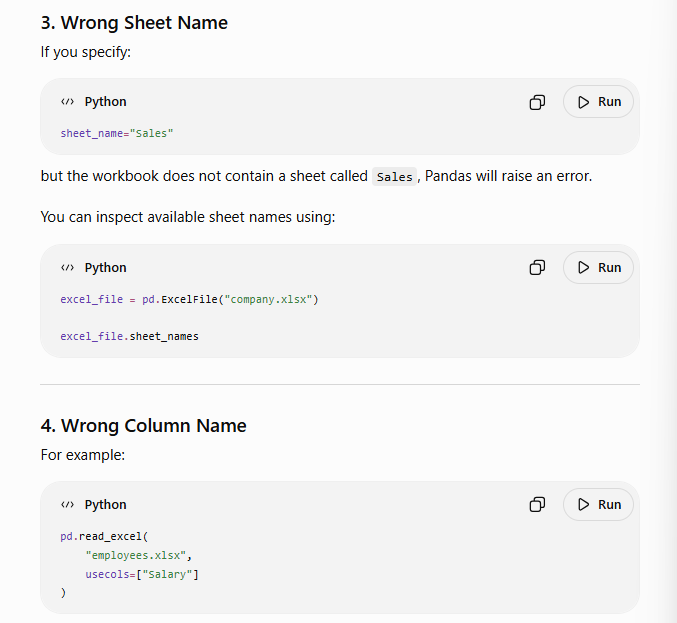


---

# SECTION 21 — Very Useful: `ExcelFile`

I would add this because it becomes useful when working with workbooks containing many sheets.

### Markdown cell

```markdown
## 17. Inspecting an Excel Workbook

`pd.ExcelFile()` allows us to work with an Excel workbook and inspect its sheets.

In [68]:
excel_file = pd.ExcelFile("company.xlsx")

excel_file.sheet_names

['Employees', 'Departments']

In [69]:
df = pd.read_excel(
    excel_file,
    sheet_name="Employees"
)

df

,Name,Age,City,Salary,Join_Date
0,Alice,21,Bangalore,45000,2024-01-10
1,Bob,22,Mumbai,50000,2023-06-15
2,Charlie,23,Delhi,55000,2022-09-20
3,David,21,Chennai,48000,2024-02-12
4,Eva,24,Pune,60000,2021-11-05


## Important `read_excel()` Parameters

| Parameter | Purpose |
|---|---|
| `io` | Excel file path or file-like object |
| `sheet_name` | Select worksheet(s) |
| `header` | Specify header row |
| `names` | Specify custom column names |
| `index_col` | Set DataFrame index |
| `usecols` | Load selected columns |
| `dtype` | Specify data types |
| `na_values` | Treat specified values as NaN |
| `skiprows` | Skip rows |
| `nrows` | Read limited rows |
| `parse_dates` | Parse date columns |
| `engine` | Specify Excel parsing engine |

# CSV vs Excel

| Feature | CSV | Excel |
|---|---|---|
| Function | `pd.read_csv()` | `pd.read_excel()` |
| Multiple sheets | No | Yes |
| Typical extension | `.csv` | `.xlsx` |
| Common delimiter | Comma | Not applicable |
| Sheet selection | No | `sheet_name` |
| Index column | `index_col` | `index_col` |
| Selected columns | `usecols` | `usecols` |
| Missing values | `na_values` | `na_values` |
| Date parsing | `parse_dates` | `parse_dates` |

Basic loading:

```python
pd.read_csv("data.csv")

# Pandas: Reading JSON Files

JSON stands for **JavaScript Object Notation**.

It is a lightweight format commonly used to store and exchange structured data.

JSON is very common when working with:

- APIs
- Web applications
- Databases
- Configuration files
- Data exchange between applications

JSON mainly represents data using:

- Objects → `{ }`
- Arrays → `[ ]`
- Key-value pairs

## 1. Basic JSON Structure

A JSON object contains key-value pairs.

Example:

{
    "name": "Alice",
    "age": 25,
    "city": "Bangalore"
}

Here:

"name" → key
"Alice" → value

"age" → key
25 → value

"city" → key
"Bangalore" → value

In [70]:
{
    "name": "Alice",
    "age": 25
}

{'name': 'Alice', 'age': 25}

## 2. JSON Arrays

A JSON array contains multiple values.

Example:

[
    {
        "id": 1,
        "name": "Alice"
    },
    {
        "id": 2,
        "name": "Bob"
    }
]

This represents multiple records.

Each object can be thought of as one row of data.

JSON
 ↓
Array
 ↓
Multiple objects
 ↓
DataFrame rows

## 3. JSON vs CSV

CSV is mainly designed for tabular data.

JSON can represent both:

- Simple tabular data
- Hierarchical/nested data

Example CSV:

Name,Age,City
Alice,21,Bangalore
Bob,22,Mumbai

Equivalent JSON:

[
    {
        "Name": "Alice",
        "Age": 21,
        "City": "Bangalore"
    },
    {
        "Name": "Bob",
        "Age": 22,
        "City": "Mumbai"
    }
]

JSON can also contain nested structures, which CSV cannot represent naturally.

## 4. Reading a JSON File Using `pd.read_json()`

`pd.read_json()` can read JSON data and convert it into a Pandas DataFrame.

### Syntax

```python
pd.read_json("file_path")


### Code cell

```python
import pandas as pd

In [71]:
data = [
    {
        "id": 1,
        "name": "Alice",
        "age": 25,
        "city": "Bangalore"
    },
    {
        "id": 2,
        "name": "Bob",
        "age": 30,
        "city": "Mumbai"
    },
    {
        "id": 3,
        "name": "Charlie",
        "age": 22,
        "city": "Delhi"
    }
]

In [72]:
import json

with open("people.json", "w") as file:
    json.dump(data, file)

In [73]:
df.head()

,Name,Age,City,Salary,Join_Date
0,Alice,21,Bangalore,45000,2024-01-10
1,Bob,22,Mumbai,50000,2023-06-15
2,Charlie,23,Delhi,55000,2022-09-20
3,David,21,Chennai,48000,2024-02-12
4,Eva,24,Pune,60000,2021-11-05


In [74]:
df.shape

(5, 5)

In [75]:
df.columns

Index(['Name', 'Age', 'City', 'Salary', 'Join_Date'], dtype='object')

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Name       5 non-null      object
 1   Age        5 non-null      int64 
 2   City       5 non-null      object
 3   Salary     5 non-null      int64 
 4   Join_Date  5 non-null      object
dtypes: int64(2), object(3)
memory usage: 332.0+ bytes


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Name       5 non-null      object
 1   Age        5 non-null      int64 
 2   City       5 non-null      object
 3   Salary     5 non-null      int64 
 4   Join_Date  5 non-null      object
dtypes: int64(2), object(3)
memory usage: 332.0+ bytes


## 5. Creating a DataFrame from JSON-like Python Data

Sometimes the JSON data has already been loaded into Python.

In that situation, we may not need `pd.read_json()`.

We can directly create a DataFrame using `pd.DataFrame()`.

## 5. Creating a DataFrame from JSON-like Python Data

Sometimes the JSON data has already been loaded into Python.

In that situation, we may not need `pd.read_json()`.

We can directly create a DataFrame using `pd.DataFrame()`.

In [78]:
data = [
    {"Name": "Alice", "Age": 25},
    {"Name": "Bob", "Age": 30},
    {"Name": "Charlie", "Age": 22}
]

df = pd.DataFrame(data)

df

,Name,Age
0,Alice,25
1,Bob,30
2,Charlie,22


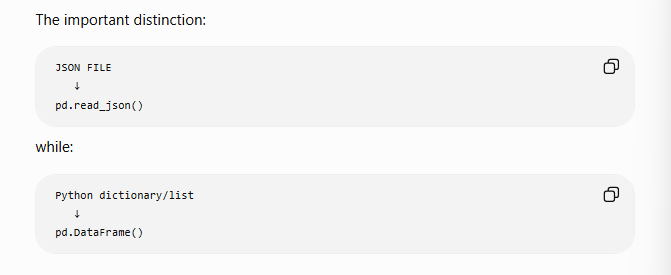

In [79]:
data = {
    "Name": ["Alice", "Bob", "Charlie"],
    "Age": [25, 30, 22],
    "City": ["Bangalore", "Mumbai", "Delhi"]
}

df = pd.DataFrame(data)

df

,Name,Age,City
0,Alice,25,Bangalore
1,Bob,30,Mumbai
2,Charlie,22,Delhi


## 6. Nested JSON

Real-world APIs often return nested JSON.

For example:

{
    "name": "Alice",
    "age": 25,
    "address": {
        "city": "Bangalore",
        "country": "India"
    }
}

Here, `address` is itself another JSON object.

This is called **nested JSON**.

A normal DataFrame expects data in rows and columns, so nested structures may need to be flattened before analysis.

## 7. Flattening Nested JSON

`pd.json_normalize()` converts nested JSON into a flat table.

It is especially useful when working with JSON responses from APIs.

In [80]:
data = [
    {
        "name": "Alice",
        "age": 25,
        "address": {
            "city": "Bangalore",
            "country": "India"
        }
    },
    {
        "name": "Bob",
        "age": 30,
        "address": {
            "city": "Mumbai",
            "country": "India"
        }
    }
]

In [81]:
df = pd.json_normalize(data)

df

,name,age,address.city,address.country
0,Alice,25,Bangalore,India
1,Bob,30,Mumbai,India


In [82]:
data = [
    {
        "id": 1,
        "name": "Alice",
        "skills": ["Python", "SQL"]
    },
    {
        "id": 2,
        "name": "Bob",
        "skills": ["Java", "C++"]
    }
]

In [83]:
df = pd.json_normalize(data)

df

,id,name,skills
0,1,Alice,"[Python, SQL]"
1,2,Bob,"[Java, C++]"


In [84]:
data = [
    {
        "name": "Alice",
        "department": "IT",
        "skills": [
            {"skill": "Python", "level": "Advanced"},
            {"skill": "SQL", "level": "Intermediate"}
        ]
    },
    {
        "name": "Bob",
        "department": "HR",
        "skills": [
            {"skill": "Excel", "level": "Advanced"}
        ]
    }
]

In [85]:
df = pd.json_normalize(
    data,
    record_path="skills"
)

df

,skill,level
0,Python,Advanced
1,SQL,Intermediate
2,Excel,Advanced


In [86]:
df = pd.json_normalize(
    data,
    record_path="skills",
    meta=["name", "department"]
)

df

,skill,level,name,department
0,Python,Advanced,Alice,IT
1,SQL,Intermediate,Alice,IT
2,Excel,Advanced,Bob,HR


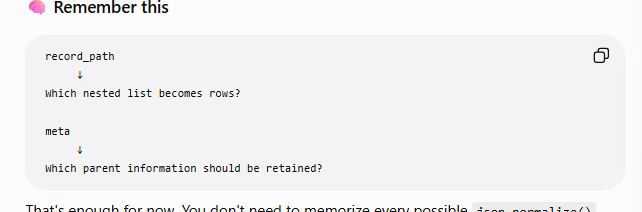

## 8. Reading JSON from a URL

JSON data can be hosted online.

Pandas can sometimes read JSON directly from a URL.

In [87]:
url = "https://jsonplaceholder.typicode.com/users"

df = pd.read_json(url)

df.head()

,id,name,username,email,address,phone,website,company
0,1,Leanne Graham,Bret,Sincere@april.biz,"{'street': 'Kulas Light', 'suite': 'Apt. 556',...",1-770-736-8031 x56442,hildegard.org,"{'name': 'Romaguera-Crona', 'catchPhrase': 'Mu..."
1,2,Ervin Howell,Antonette,Shanna@melissa.tv,"{'street': 'Victor Plains', 'suite': 'Suite 87...",010-692-6593 x09125,anastasia.net,"{'name': 'Deckow-Crist', 'catchPhrase': 'Proac..."
2,3,Clementine Bauch,Samantha,Nathan@yesenia.net,"{'street': 'Douglas Extension', 'suite': 'Suit...",1-463-123-4447,ramiro.info,"{'name': 'Romaguera-Jacobson', 'catchPhrase': ..."
3,4,Patricia Lebsack,Karianne,Julianne.OConner@kory.org,"{'street': 'Hoeger Mall', 'suite': 'Apt. 692',...",493-170-9623 x156,kale.biz,"{'name': 'Robel-Corkery', 'catchPhrase': 'Mult..."
4,5,Chelsey Dietrich,Kamren,Lucio_Hettinger@annie.ca,"{'street': 'Skiles Walks', 'suite': 'Suite 351...",(254)954-1289,demarco.info,"{'name': 'Keebler LLC', 'catchPhrase': 'User-c..."


In [88]:
df.columns

Index(['id', 'name', 'username', 'email', 'address', 'phone', 'website',
       'company'],
      dtype='object')

In [89]:
df.shape

(10, 8)

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        10 non-null     int64 
 1   name      10 non-null     object
 2   username  10 non-null     object
 3   email     10 non-null     object
 4   address   10 non-null     object
 5   phone     10 non-null     object
 6   website   10 non-null     object
 7   company   10 non-null     object
dtypes: int64(1), object(7)
memory usage: 772.0+ bytes


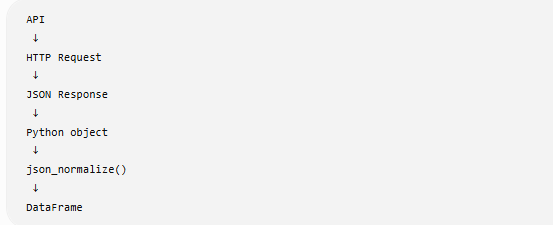

In [91]:
import requests

response = requests.get(
    "https://jsonplaceholder.typicode.com/users"
)

data = response.json()

data

[{'id': 1,
  'name': 'Leanne Graham',
  'username': 'Bret',
  'email': 'Sincere@april.biz',
  'address': {'street': 'Kulas Light',
   'suite': 'Apt. 556',
   'city': 'Gwenborough',
   'zipcode': '92998-3874',
   'geo': {'lat': '-37.3159', 'lng': '81.1496'}},
  'phone': '1-770-736-8031 x56442',
  'website': 'hildegard.org',
  'company': {'name': 'Romaguera-Crona',
   'catchPhrase': 'Multi-layered client-server neural-net',
   'bs': 'harness real-time e-markets'}},
 {'id': 2,
  'name': 'Ervin Howell',
  'username': 'Antonette',
  'email': 'Shanna@melissa.tv',
  'address': {'street': 'Victor Plains',
   'suite': 'Suite 879',
   'city': 'Wisokyburgh',
   'zipcode': '90566-7771',
   'geo': {'lat': '-43.9509', 'lng': '-34.4618'}},
  'phone': '010-692-6593 x09125',
  'website': 'anastasia.net',
  'company': {'name': 'Deckow-Crist',
   'catchPhrase': 'Proactive didactic contingency',
   'bs': 'synergize scalable supply-chains'}},
 {'id': 3,
  'name': 'Clementine Bauch',
  'username': 'Samantha

In [92]:
df = pd.json_normalize(data)

df

,id,name,username,email,phone,website,address.street,address.suite,address.city,address.zipcode,address.geo.lat,address.geo.lng,company.name,company.catchPhrase,company.bs
0,1,Leanne Graham,Bret,Sincere@april.biz,1-770-736-8031 x56442,hildegard.org,Kulas Light,Apt. 556,Gwenborough,92998-3874,-37.3159,81.1496,Romaguera-Crona,Multi-layered client-server neural-net,harness real-time e-markets
1,2,Ervin Howell,Antonette,Shanna@melissa.tv,010-692-6593 x09125,anastasia.net,Victor Plains,Suite 879,Wisokyburgh,90566-7771,-43.9509,-34.4618,Deckow-Crist,Proactive didactic contingency,synergize scalable supply-chains
2,3,Clementine Bauch,Samantha,Nathan@yesenia.net,1-463-123-4447,ramiro.info,Douglas Extension,Suite 847,McKenziehaven,59590-4157,-68.6102,-47.0653,Romaguera-Jacobson,Face to face bifurcated interface,e-enable strategic applications
3,4,Patricia Lebsack,Karianne,Julianne.OConner@kory.org,493-170-9623 x156,kale.biz,Hoeger Mall,Apt. 692,South Elvis,53919-4257,29.4572,-164.2990,Robel-Corkery,Multi-tiered zero tolerance productivity,transition cutting-edge web services
4,5,Chelsey Dietrich,Kamren,Lucio_Hettinger@annie.ca,(254)954-1289,demarco.info,Skiles Walks,Suite 351,Roscoeview,33263,-31.8129,62.5342,Keebler LLC,User-centric fault-tolerant solution,revolutionize end-to-end systems
5,6,Mrs. Dennis Schulist,Leopoldo_Corkery,Karley_Dach@jasper.info,1-477-935-8478 x6430,ola.org,Norberto Crossing,Apt. 950,South Christy,23505-1337,-71.4197,71.7478,Considine-Lockman,Synchronised bottom-line interface,e-enable innovative applications
6,7,Kurtis Weissnat,Elwyn.Skiles,Telly.Hoeger@billy.biz,210.067.6132,elvis.io,Rex Trail,Suite 280,Howemouth,58804-1099,24.8918,21.8984,Johns Group,Configurable multimedia task-force,generate enterprise e-tailers
7,8,Nicholas Runolfsdottir V,Maxime_Nienow,Sherwood@rosamond.me,586.493.6943 x140,jacynthe.com,Ellsworth Summit,Suite 729,Aliyaview,45169,-14.3990,-120.7677,Abernathy Group,Implemented secondary concept,e-enable extensible e-tailers
8,9,Glenna Reichert,Delphine,Chaim_McDermott@dana.io,(775)976-6794 x41206,conrad.com,Dayna Park,Suite 449,Bartholomebury,76495-3109,24.6463,-168.8889,Yost and Sons,Switchable contextually-based project,aggregate real-time technologies
9,10,Clementina DuBuque,Moriah.Stanton,Rey.Padberg@karina.biz,024-648-3804,ambrose.net,Kattie Turnpike,Suite 198,Lebsackbury,31428-2261,-38.2386,57.2232,Hoeger LLC,Centralized empowering task-force,target end-to-end models


## 9. `json.load()` vs `json.loads()`

Python's built-in `json` module provides functions for working with JSON.

### `json.load()`

Used to read JSON from a file.

```python
with open("data.json", "r") as file:
    data = json.load(file)

In [93]:
json_string = '{"name": "Alice", "age": 25}'

data = json.loads(json_string)


The **s** in `loads` can help you remember **string**.

---

# SECTION 17 — JSON Orientations

This is a slightly more advanced but useful `read_json()` concept.

JSON can represent tabular data in different orientations.

For example:

```python
data = {
    "Name": ["Alice", "Bob"],
    "Age": [25, 30]
}

In [94]:
# orient tells Pandas how the JSON data is structured.

# This becomes useful when read_json() doesn't automatically interpret the JSON the way you expect.
# pd.read_json(
#     "data.json",
#     orient="records"
# )


# Common JSON Loading Errors

## 1. JSONDecodeError

This usually means the JSON structure is invalid.

Check:
- Missing commas
- Incorrect quotes
- Missing brackets
- Invalid JSON syntax

---

## 2. ValueError / Unexpected JSON Structure

The JSON may not have the structure expected by `pd.read_json()`.

Try:
- Inspecting the raw JSON
- Using `json.load()` / `json.loads()`
- Using `pd.json_normalize()`

---

## 3. Nested JSON Not Appearing as Expected

If the JSON contains nested dictionaries or lists, `pd.read_json()` may not produce the desired tabular structure.

Use:

```python
pd.json_normalize(data)


---

# SECTION 19 — Complete Real-World Example

This is the example I'd definitely keep in your Colab.

### Markdown

```markdown
# Real-World Example: JSON API → DataFrame

A common Data Science workflow is:

API
 ↓
requests
 ↓
JSON
 ↓
json_normalize
 ↓
DataFrame

In [95]:
import requests
import pandas as pd

In [96]:
url = "https://jsonplaceholder.typicode.com/users"

response = requests.get(url)

response.status_code

200

In [97]:
data = response.json()

data[:2]

[{'id': 1,
  'name': 'Leanne Graham',
  'username': 'Bret',
  'email': 'Sincere@april.biz',
  'address': {'street': 'Kulas Light',
   'suite': 'Apt. 556',
   'city': 'Gwenborough',
   'zipcode': '92998-3874',
   'geo': {'lat': '-37.3159', 'lng': '81.1496'}},
  'phone': '1-770-736-8031 x56442',
  'website': 'hildegard.org',
  'company': {'name': 'Romaguera-Crona',
   'catchPhrase': 'Multi-layered client-server neural-net',
   'bs': 'harness real-time e-markets'}},
 {'id': 2,
  'name': 'Ervin Howell',
  'username': 'Antonette',
  'email': 'Shanna@melissa.tv',
  'address': {'street': 'Victor Plains',
   'suite': 'Suite 879',
   'city': 'Wisokyburgh',
   'zipcode': '90566-7771',
   'geo': {'lat': '-43.9509', 'lng': '-34.4618'}},
  'phone': '010-692-6593 x09125',
  'website': 'anastasia.net',
  'company': {'name': 'Deckow-Crist',
   'catchPhrase': 'Proactive didactic contingency',
   'bs': 'synergize scalable supply-chains'}}]

In [98]:
df = pd.json_normalize(data)

df.head()

,id,name,username,email,phone,website,address.street,address.suite,address.city,address.zipcode,address.geo.lat,address.geo.lng,company.name,company.catchPhrase,company.bs
0,1,Leanne Graham,Bret,Sincere@april.biz,1-770-736-8031 x56442,hildegard.org,Kulas Light,Apt. 556,Gwenborough,92998-3874,-37.3159,81.1496,Romaguera-Crona,Multi-layered client-server neural-net,harness real-time e-markets
1,2,Ervin Howell,Antonette,Shanna@melissa.tv,010-692-6593 x09125,anastasia.net,Victor Plains,Suite 879,Wisokyburgh,90566-7771,-43.9509,-34.4618,Deckow-Crist,Proactive didactic contingency,synergize scalable supply-chains
2,3,Clementine Bauch,Samantha,Nathan@yesenia.net,1-463-123-4447,ramiro.info,Douglas Extension,Suite 847,McKenziehaven,59590-4157,-68.6102,-47.0653,Romaguera-Jacobson,Face to face bifurcated interface,e-enable strategic applications
3,4,Patricia Lebsack,Karianne,Julianne.OConner@kory.org,493-170-9623 x156,kale.biz,Hoeger Mall,Apt. 692,South Elvis,53919-4257,29.4572,-164.2990,Robel-Corkery,Multi-tiered zero tolerance productivity,transition cutting-edge web services
4,5,Chelsey Dietrich,Kamren,Lucio_Hettinger@annie.ca,(254)954-1289,demarco.info,Skiles Walks,Suite 351,Roscoeview,33263,-31.8129,62.5342,Keebler LLC,User-centric fault-tolerant solution,revolutionize end-to-end systems


In [99]:
df.shape

(10, 15)

In [100]:
df.columns

Index(['id', 'name', 'username', 'email', 'phone', 'website', 'address.street',
       'address.suite', 'address.city', 'address.zipcode', 'address.geo.lat',
       'address.geo.lng', 'company.name', 'company.catchPhrase', 'company.bs'],
      dtype='object')

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   10 non-null     int64 
 1   name                 10 non-null     object
 2   username             10 non-null     object
 3   email                10 non-null     object
 4   phone                10 non-null     object
 5   website              10 non-null     object
 6   address.street       10 non-null     object
 7   address.suite        10 non-null     object
 8   address.city         10 non-null     object
 9   address.zipcode      10 non-null     object
 10  address.geo.lat      10 non-null     object
 11  address.geo.lng      10 non-null     object
 12  company.name         10 non-null     object
 13  company.catchPhrase  10 non-null     object
 14  company.bs           10 non-null     object
dtypes: int64(1), object(14)
memory usage: 1.3+ KB


In [102]:
df[
    [
        "name",
        "email",
        "address.city",
        "company.name"
    ]
]

,name,email,address.city,company.name
0,Leanne Graham,Sincere@april.biz,Gwenborough,Romaguera-Crona
1,Ervin Howell,Shanna@melissa.tv,Wisokyburgh,Deckow-Crist
2,Clementine Bauch,Nathan@yesenia.net,McKenziehaven,Romaguera-Jacobson
3,Patricia Lebsack,Julianne.OConner@kory.org,South Elvis,Robel-Corkery
4,Chelsey Dietrich,Lucio_Hettinger@annie.ca,Roscoeview,Keebler LLC
5,Mrs. Dennis Schulist,Karley_Dach@jasper.info,South Christy,Considine-Lockman
6,Kurtis Weissnat,Telly.Hoeger@billy.biz,Howemouth,Johns Group
7,Nicholas Runolfsdottir V,Sherwood@rosamond.me,Aliyaview,Abernathy Group
8,Glenna Reichert,Chaim_McDermott@dana.io,Bartholomebury,Yost and Sons
9,Clementina DuBuque,Rey.Padberg@karina.biz,Lebsackbury,Hoeger LLC


# CSV vs Excel vs JSON

| Feature | CSV | Excel | JSON |
|---|---|---|---|
| Pandas function | `read_csv()` | `read_excel()` | `read_json()` |
| Tabular data | Yes | Yes | Yes |
| Multiple sheets | No | Yes | No |
| Nested data | No | Limited | Yes |
| Common in APIs | Rare | Rare | Very common |
| Main special concept | `sep` | `sheet_name` | `json_normalize()` |

Basic loading:

```python
pd.read_csv("data.csv")

In [103]:
#pd.read_excel("data.xlsx")

In [104]:
#pd.read_json("data.json")

In [105]:
df = pd.DataFrame(data)

In [106]:
df = pd.json_normalize(data)

In [107]:
data = {
    "name": "John",
    "items": [
        {"product": "Laptop", "price": 50000},
        {"product": "Mouse", "price": 1000}
    ]
}

In [108]:
df = pd.json_normalize(
    data,
    record_path="items"
)

In [109]:
df = pd.json_normalize(
    data,
    record_path="items",
    meta=["name"]
)

In [110]:
response = requests.get(url)
data = response.json()

df = pd.json_normalize(data)

# Pandas: Reading Data from SQL Databases

SQL databases store structured data in tables.

A database can contain multiple tables.

For example:

Company Database
│
├── Employees
├── Departments
└── Sales

Each table contains rows and columns.

Pandas can load data from these SQL tables into a DataFrame for analysis.

## 1. SQL Database to Pandas DataFrame

The general workflow is:

SQL Database

     ↓

SQLAlchemy

     ↓

Database Connection

     ↓

Pandas

     ↓
     
DataFrame

Once the data is in a DataFrame, we can use Pandas for analysis and visualization.

## 2. SQL vs Pandas

SQL is commonly used to retrieve and manipulate data inside a database.

Pandas is commonly used to analyze and manipulate data after it has been loaded into Python.

Example SQL:

```sql
SELECT name, salary
FROM employees
WHERE salary > 50000;


The mental model:

```text
Database
   ↓
SQL → retrieve required data
   ↓
Pandas DataFrame
   ↓
Python → analyze

## 3. Installing SQLAlchemy

SQLAlchemy provides tools for connecting Python applications to SQL databases.

For this tutorial, we will use SQLite because it does not require a separate database server.

In [111]:
!pip install sqlalchemy

In [112]:
import pandas as pd
from sqlalchemy import create_engine, text

## 4. SQLite

SQLite is a lightweight SQL database.

Unlike databases such as MySQL or PostgreSQL, SQLite stores the database in a file.

For example:

```text
company.db


---

# SECTION 6 — Create Database Connection

### Code cell

```python
from sqlalchemy import create_engine

engine = create_engine("sqlite:///company.db")

sqlite:///company.db
       ↓
SQLite database
       ↓
company.db

In [113]:
from sqlalchemy import create_engine, text

In [114]:
engine = create_engine("sqlite:///employees.db")

In [115]:
from sqlalchemy import text

with engine.begin() as connection:
    connection.execute(text("""
        CREATE TABLE IF NOT EXISTS employees (
            id INTEGER,
            name TEXT,
            department TEXT,
            salary INTEGER,
            joining_date TEXT
        )
    """))

In [116]:
with engine.begin() as connection:
    connection.execute(text("""
        DELETE FROM employees
    """))

    connection.execute(text("""
        INSERT INTO employees
        VALUES
        (1, 'Alice', 'IT', 60000, '2023-01-10'),
        (2, 'Bob', 'HR', 45000, '2022-06-15'),
        (3, 'Charlie', 'Finance', 75000, '2021-09-20'),
        (4, 'David', 'IT', 55000, '2024-02-12'),
        (5, 'Eva', 'Marketing', 50000, '2023-11-05')
    """))

## 5. Reading an Entire SQL Table

`pd.read_sql_table()` reads an entire SQL table into a Pandas DataFrame.

### Syntax

```python
pd.read_sql_table(
    table_name,
    con
)


### Code cell

```python
df = pd.read_sql_table(
    "employees",
    engine
)

df

## 6. Selecting Columns While Reading a Table

The `columns` parameter allows us to specify which columns should be loaded.

In [117]:
df = pd.read_sql_table(
    "employees",
    engine,
    columns=["name", "salary"]
)

df





,name,salary
0,Alice,60000
1,Bob,45000
2,Charlie,75000
3,David,55000
4,Eva,50000


## 7. Setting an Index Column

We can use `index_col` to make a column the DataFrame index.

In [118]:
df = pd.read_sql_table(
    "employees",
    engine,
    index_col="id"
)

df

,name,department,salary,joining_date
id,,,,
1,Alice,IT,60000,2023-01-10
2,Bob,HR,45000,2022-06-15
3,Charlie,Finance,75000,2021-09-20
4,David,IT,55000,2024-02-12
5,Eva,Marketing,50000,2023-11-05


## 8. Reading SQL Queries with Pandas

`pd.read_sql()` allows us to execute a SQL query and load the result into a DataFrame.

This is more flexible than `read_sql_table()` because we can use SQL operations such as:

- SELECT
- WHERE
- ORDER BY
- GROUP BY
- JOIN

In [119]:
query = """
SELECT *
FROM employees
"""

df = pd.read_sql(
    query,
    engine
)

df

,id,name,department,salary,joining_date
0,1,Alice,IT,60000,2023-01-10
1,2,Bob,HR,45000,2022-06-15
2,3,Charlie,Finance,75000,2021-09-20
3,4,David,IT,55000,2024-02-12
4,5,Eva,Marketing,50000,2023-11-05


In [120]:
query = """
SELECT name, department, salary
FROM employees
"""

df = pd.read_sql(
    query,
    engine
)

df

,name,department,salary
0,Alice,IT,60000
1,Bob,HR,45000
2,Charlie,Finance,75000
3,David,IT,55000
4,Eva,Marketing,50000


In [121]:
query = """
SELECT *
FROM employees
WHERE salary > 50000
"""

df = pd.read_sql(
    query,
    engine
)

df

,id,name,department,salary,joining_date
0,1,Alice,IT,60000,2023-01-10
1,3,Charlie,Finance,75000,2021-09-20
2,4,David,IT,55000,2024-02-12


In [122]:
query = """
SELECT name, salary
FROM employees
ORDER BY salary DESC
"""

df = pd.read_sql(
    query,
    engine
)

df

,name,salary
0,Charlie,75000
1,Alice,60000
2,David,55000
3,Eva,50000
4,Bob,45000


In [123]:
query = """
SELECT department, AVG(salary) AS average_salary
FROM employees
GROUP BY department
"""

df = pd.read_sql(
    query,
    engine
)

df

,department,average_salary
0,Finance,75000.0
1,HR,45000.0
2,IT,57500.0
3,Marketing,50000.0


In [124]:
with engine.begin() as connection:
    connection.execute(text("""
        CREATE TABLE IF NOT EXISTS departments (
            department TEXT,
            manager TEXT
        )
    """))

    connection.execute(text("""
        DELETE FROM departments
    """))

    connection.execute(text("""
        INSERT INTO departments
        VALUES
        ('IT', 'Rahul'),
        ('HR', 'Priya'),
        ('Finance', 'Arjun'),
        ('Marketing', 'Sneha')
    """))

In [125]:
query = """
SELECT
    e.name,
    e.department,
    e.salary,
    d.manager
FROM employees e
JOIN departments d
ON e.department = d.department
"""

df = pd.read_sql(
    query,
    engine
)

df

,name,department,salary,manager
0,Alice,IT,60000,Rahul
1,Bob,HR,45000,Priya
2,Charlie,Finance,75000,Arjun
3,David,IT,55000,Rahul
4,Eva,Marketing,50000,Sneha


In [126]:
df = pd.read_sql_table(
    "employees",
    engine,
    parse_dates=["joining_date"]
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            5 non-null      int64         
 1   name          5 non-null      object        
 2   department    5 non-null      object        
 3   salary        5 non-null      int64         
 4   joining_date  5 non-null      datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 332.0+ bytes


## 9. Reading Large Tables in Chunks

A very large database table may not fit comfortably into memory.

`chunksize` allows us to read the data in smaller pieces.

In [127]:
chunks = pd.read_sql_table(
    "employees",
    engine,
    chunksize=2
)

In [128]:
for chunk in chunks:
    print(chunk)

   id   name department  salary joining_date
0   1  Alice         IT   60000   2023-01-10
1   2    Bob         HR   45000   2022-06-15
   id     name department  salary joining_date
0   3  Charlie    Finance   75000   2021-09-20
1   4    David         IT   55000   2024-02-12
   id name department  salary joining_date
0   5  Eva  Marketing   50000   2023-11-05


# Common SQL Loading Errors

## 1. Database Connection Error

The database connection string may be incorrect.

Check:

- Database path
- Username/password
- Host
- Port
- Database name

---

## 2. Table Not Found

If you run:

```python
pd.read_sql_table("employees", engine)


---

# SECTION 20 — `read_sql_table()` vs `read_sql()`

This is **one of the most important things to remember from this module**.

### Markdown cell

```markdown
# `read_sql_table()` vs `read_sql()`

## `read_sql_table()`

Used when you want to read a table.

```python
df = pd.read_sql_table(
    "employees",
    engine
)

In [129]:
query = """
SELECT name, salary
FROM employees
WHERE salary > 50000
"""

df = pd.read_sql(
    query,
    engine
)


---

# SECTION 21 — `read_sql_query()`

There's one more function you may encounter.

```python
df = pd.read_sql_query(
    "SELECT * FROM employees",
    engine
)

# Real-World SQL → Pandas Workflow

Database

  ↓

SQLAlchemy

   ↓

Create database connection

   ↓

SQL query

   ↓

Pandas

   ↓

DataFrame

   ↓

Data cleaning
   
   ↓

Data analysis
   
   ↓
   
Visualization

In [130]:
from sqlalchemy import create_engine, text
import pandas as pd

engine = create_engine("sqlite:///company.db")

with engine.begin() as connection:
    connection.execute(text("""
        CREATE TABLE IF NOT EXISTS employees (
            id INTEGER,
            name TEXT,
            department TEXT,
            salary INTEGER,
            joining_date TEXT
        )
    """))

In [131]:
with engine.begin() as connection:
    connection.execute(text("""
        INSERT INTO employees VALUES
        (1, 'Alice', 'IT', 60000, '2023-01-10'),
        (2, 'Bob', 'HR', 45000, '2022-05-15'),
        (3, 'Charlie', 'IT', 75000, '2021-08-20'),
        (4, 'David', 'Finance', 55000, '2024-02-01')
    """))

In [132]:
query = """
SELECT name, department, salary
FROM employees
WHERE salary > 50000
"""

df = pd.read_sql(
    query,
    engine
)

df

,name,department,salary
0,Alice,IT,60000
1,Charlie,IT,75000
2,David,Finance,55000


## Important SQL Loading Parameters

| Parameter | Purpose |
|---|---|
| `table_name` | Name of SQL table |
| `con` | Database connection/engine |
| `schema` | Database schema |
| `index_col` | Column used as DataFrame index |
| `columns` | Columns to load |
| `parse_dates` | Convert columns to datetime |
| `chunksize` | Read data in chunks |
| `coerce_float` | Convert numeric-like values to floats |

For `pd.read_sql()`, the important arguments are:

| Parameter | Purpose |
|---|---|
| `sql` | SQL query or table name |
| `con` | Database connection |
| `index_col` | Set DataFrame index |
| `parse_dates` | Parse date columns |
| `chunksize` | Read results in chunks |

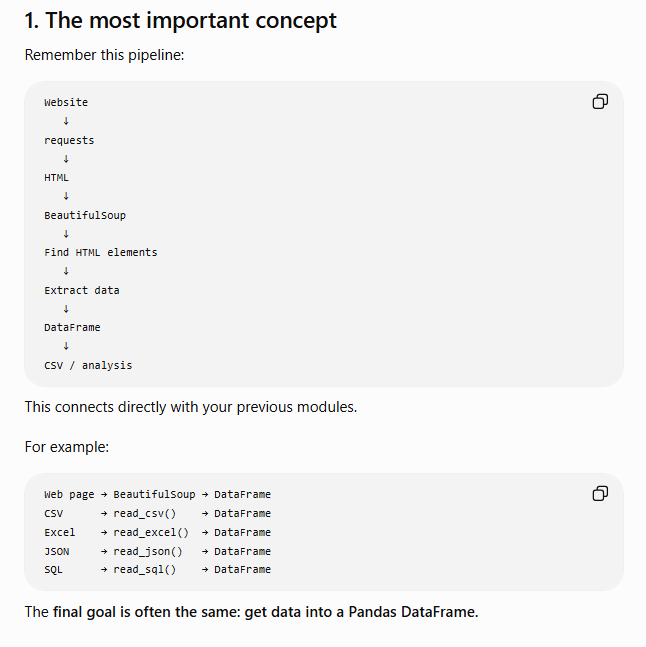

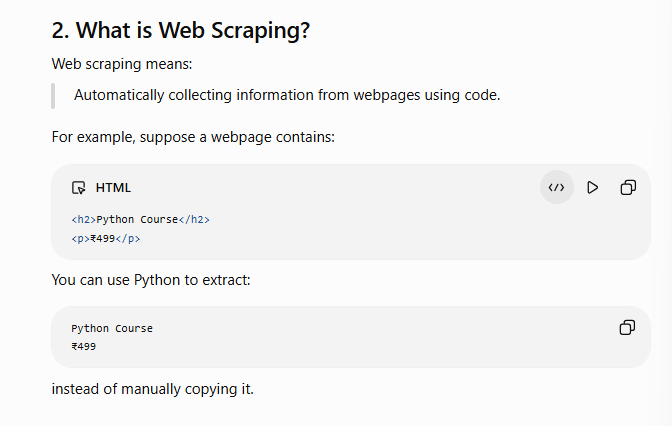

In [133]:
import requests
from bs4 import BeautifulSoup

In [134]:
!pip install requests beautifulsoup4

In [ ]:
import requests

url = "https://example.com"

response = requests.get(url)

print(response.status_code)

In [136]:
response = requests.get(url)

In [137]:
response = requests.get(url)

response.raise_for_status()

In [138]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(response.text, "html.parser")

In [139]:
print(soup.prettify())

<!DOCTYPE html>
<html lang="en">
 <head>
  <title>
   Example Domain
  </title>
  <link href="data:," rel="icon"/>
  <meta content="width=device-width, initial-scale=1" name="viewport"/>
  <style>
   body{background:#eee;width:60vw;margin:15vh auto;font-family:system-ui,sans-serif}h1{font-size:1.5em}div{opacity:0.8}a:link,a:visited{color:#348}
  </style>
 </head>
 <body>
  <div>
   <h1>
    Example Domain
   </h1>
   <p>
    This domain is for use in documentation examples without needing permission. Avoid use in operations.
   </p>
   <p>
    <a href="https://iana.org/domains/example">
     Learn more
    </a>
   </p>
  </div>
 </body>
</html>



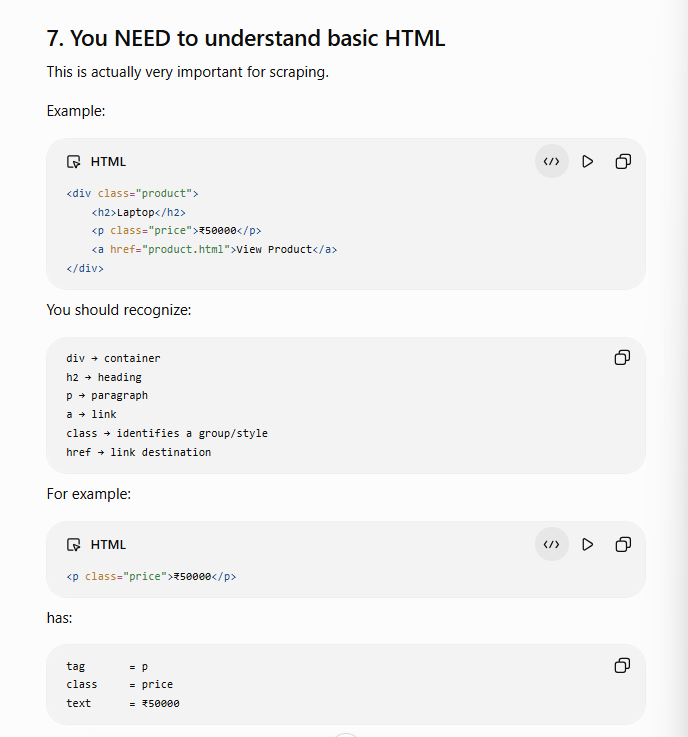

In [140]:
heading = soup.find("h2")

print(heading)

None


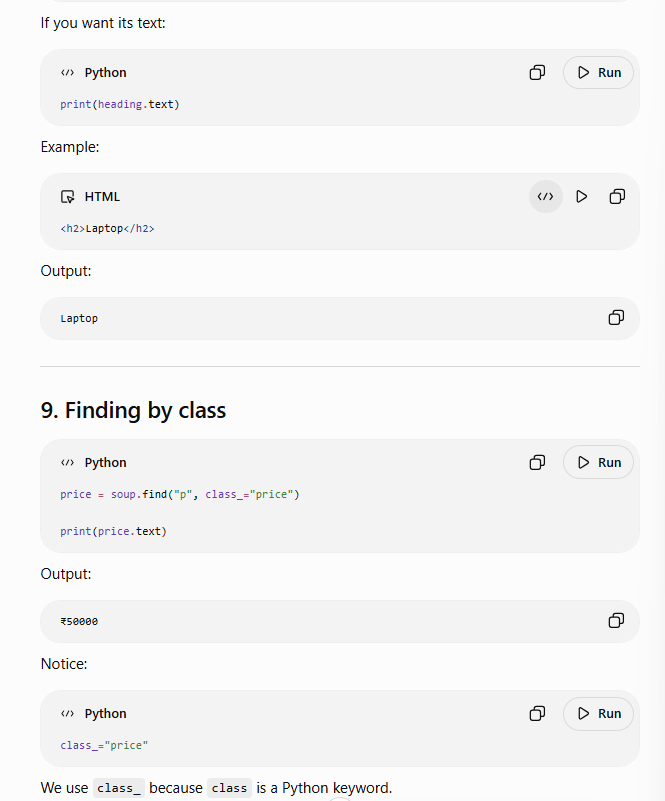

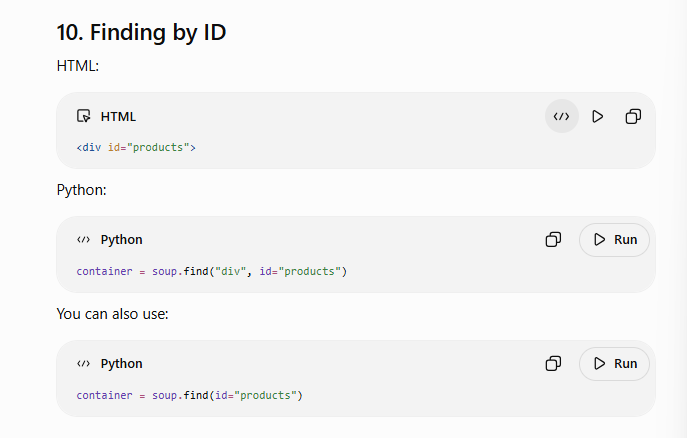

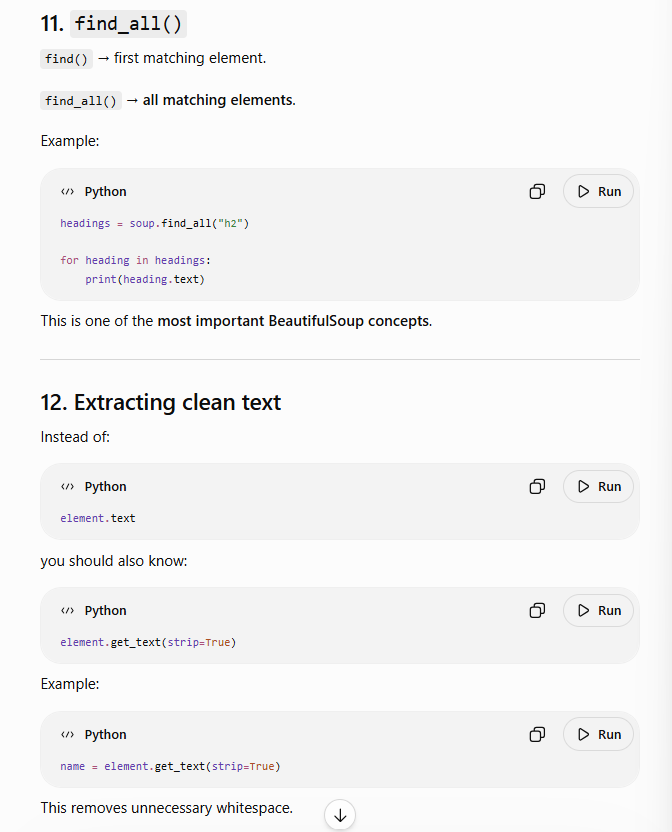

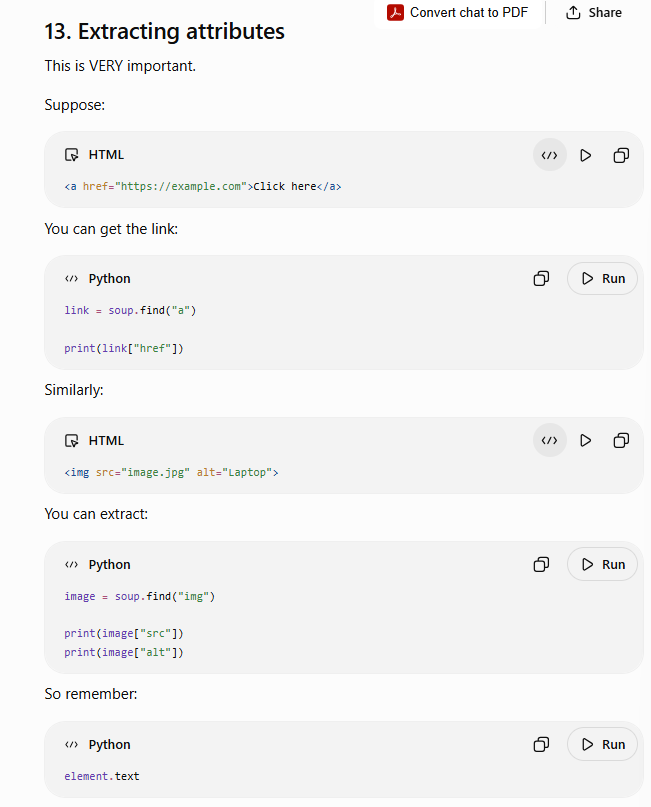

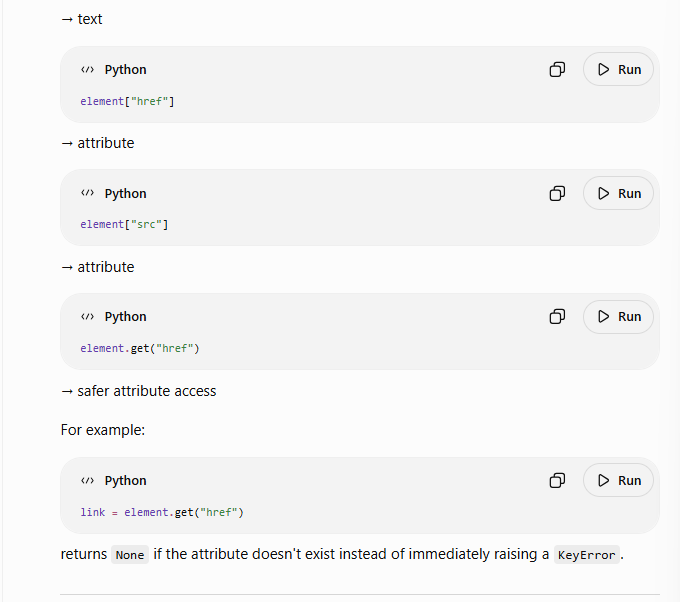

CSS Selectors

In [141]:
element = soup.select_one("h2")

In [142]:
elements = soup.select("h2")

In [143]:
elements = soup.select(".price")

In [144]:
element = soup.select_one("#products")

In [145]:
elements = soup.select("div.product")

## Practical BeautifulSoup Example

We will create a small HTML page containing products and then extract:
- Product name
- Price
- Product link

In [146]:
from bs4 import BeautifulSoup

html = """
<html>
<body>

<div class="product">
    <h2>Laptop</h2>
    <p class="price">₹50000</p>
    <a href="laptop.html">View Product</a>
</div>

<div class="product">
    <h2>Phone</h2>
    <p class="price">₹30000</p>
    <a href="phone.html">View Product</a>
</div>

<div class="product">
    <h2>Headphones</h2>
    <p class="price">₹5000</p>
    <a href="headphones.html">View Product</a>
</div>

</body>
</html>
"""

soup = BeautifulSoup(html, "html.parser")

In [147]:
products = soup.find_all("div", class_="product")

for product in products:
    name = product.find("h2").get_text(strip=True)
    price = product.find("p", class_="price").get_text(strip=True)
    link = product.find("a").get("href")

    print(name, price, link)

Laptop ₹50000 laptop.html
Phone ₹30000 phone.html
Headphones ₹5000 headphones.html


In [148]:
import pandas as pd

data = []

for product in products:
    name = product.find("h2").get_text(strip=True)
    price = product.find("p", class_="price").get_text(strip=True)
    link = product.find("a").get("href")

    data.append({
        "name": name,
        "price": price,
        "link": link
    })

df = pd.DataFrame(data)

df

,name,price,link
0,Laptop,₹50000,laptop.html
1,Phone,₹30000,phone.html
2,Headphones,₹5000,headphones.html


In [149]:
df.to_csv("products.csv", index=False)

In [150]:
pd.read_csv("products.csv")

,name,price,link
0,Laptop,₹50000,laptop.html
1,Phone,₹30000,phone.html
2,Headphones,₹5000,headphones.html


In [151]:
import requests
from bs4 import BeautifulSoup

url = "https://books.toscrape.com/"

response = requests.get(url)
response.raise_for_status()

soup = BeautifulSoup(response.text, "html.parser")

In [152]:
books = soup.select("article.product_pod")

data = []

for book in books:
    title = book.select_one("h3 a")["title"]
    price = book.select_one(".price_color").get_text(strip=True)

    data.append({
        "title": title,
        "price": price
    })

df = pd.DataFrame(data)

df.head()

,title,price
0,A Light in the Attic,Â£51.77
1,Tipping the Velvet,Â£53.74
2,Soumission,Â£50.10
3,Sharp Objects,Â£47.82
4,Sapiens: A Brief History of Humankind,Â£54.23


User-Agent

The article says to use a browser User-Agent if you get 403.

That's useful, but don't think:

"Adding User-Agent always bypasses 403."

It doesn't.

Some websites use authentication, bot detection, rate limits, JavaScript challenges, or other protections.

In [153]:
headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(
    url,
    headers=headers
)

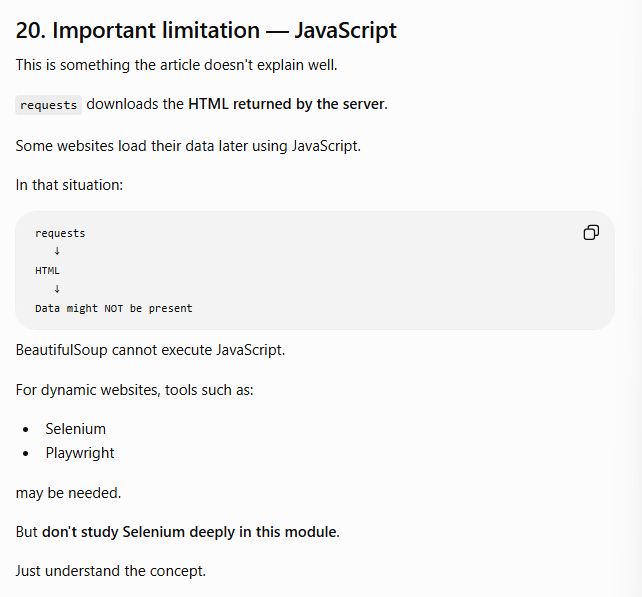

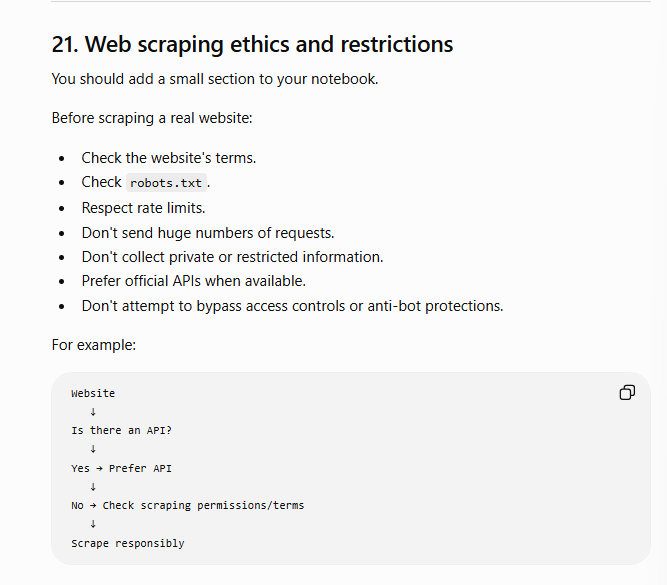

What about robots.txt?

You don't need advanced theory.

Just understand that websites can publish crawling instructions at:

In [154]:
import requests

robots_url = "https://example.com/robots.txt"

response = requests.get(robots_url)

print(response.text)

<!doctype html><html lang="en"><head><title>Example Domain</title><link rel="icon" href="data:,"><meta name="viewport" content="width=device-width, initial-scale=1"><style>body{background:#eee;width:60vw;margin:15vh auto;font-family:system-ui,sans-serif}h1{font-size:1.5em}div{opacity:0.8}a:link,a:visited{color:#348}</style></head><body><div><h1>Example Domain</h1><p>This domain is for use in documentation examples without needing permission. Avoid use in operations.</p><p><a href="https://iana.org/domains/example">Learn more</a></p></div></body></html>



In [155]:
import time

time.sleep(1)

In [156]:
# for url in urls:
#     response = requests.get(url)

#     # process data

#     time.sleep(1)

In [157]:
import requests

try:
    response = requests.get(url, timeout=10)
    response.raise_for_status()

except requests.RequestException as e:
    print("Request failed:", e)

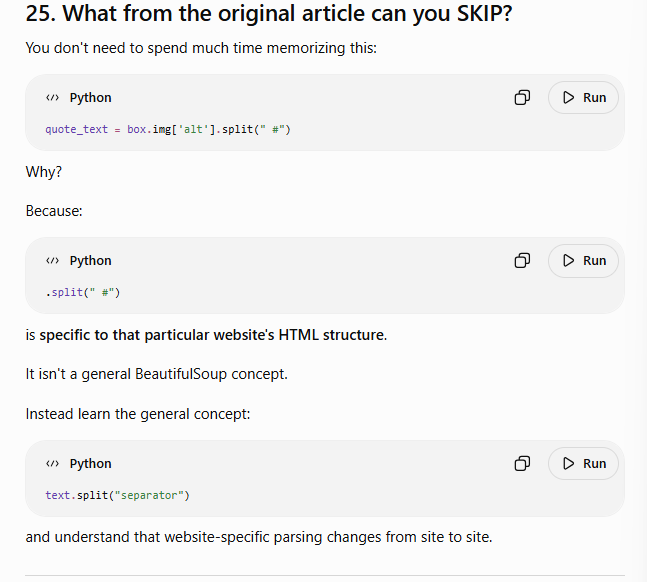

In [158]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [159]:
response = requests.get(url, timeout=10)
response.raise_for_status()

In [160]:
soup = BeautifulSoup(response.text, "html.parser")

In [161]:
soup.find("tag")

In [162]:
soup.find_all("tag")

[]

In [163]:
soup.find("tag", class_="class_name")

In [164]:
soup.find("tag", id="id_name")

In [165]:
if element:
    text = element.get_text(strip=True)
    print(text)
else:
    print("Element not found")

Element not found


In [166]:
if element:
  text=element.get("href")
  print(text)
else:
  print("element not found")

element not found


In [167]:
soup.select("CSS selector")

[]

In [168]:
soup.select("CSS selector")

[]

In [169]:
df = pd.DataFrame(data)

In [170]:
df.to_csv("data.csv", index=False)

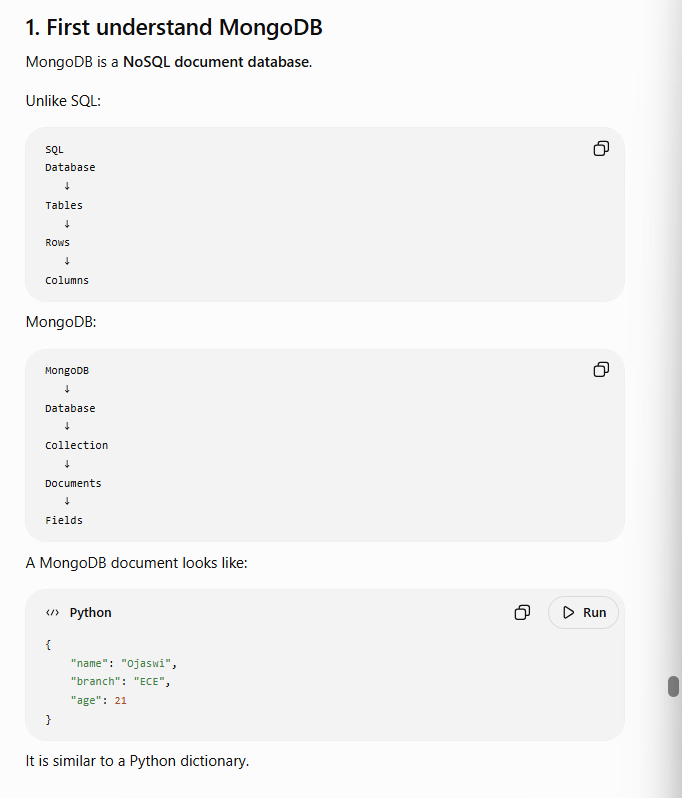

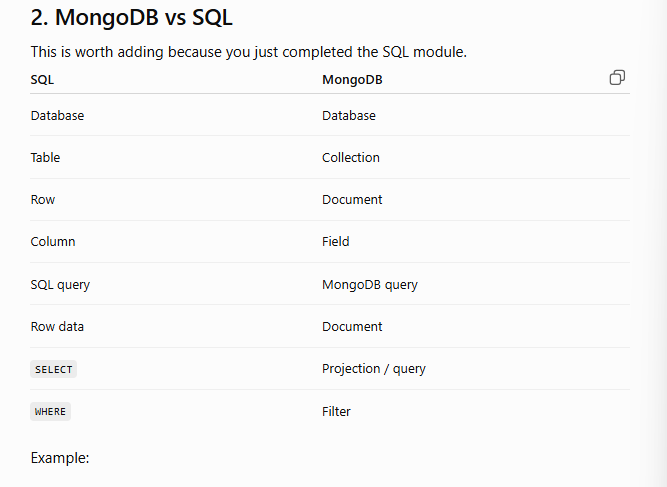

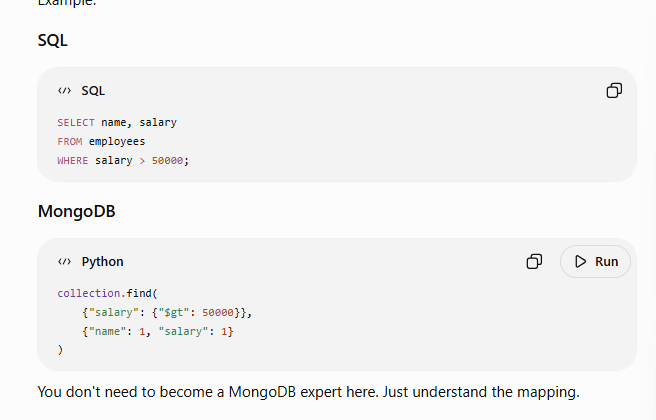

In [171]:
!pip install pymongo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 23.0 MB/s eta 0:00:00


In [172]:
from pymongo import MongoClient

In [173]:
client = MongoClient("localhost", 27017)

In [174]:
MongoClient("localhost", 27017)

MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True)

In [175]:
client = MongoClient("YOUR_MONGODB_CONNECTION_STRING")

In [176]:
db = client["college"]

In [177]:
collection = db["students"]

In [178]:
{
    "_id": 1,
    "name": "Vishwash",
    "roll_no": 1001,
    "branch": "CSE"
}

{'_id': 1, 'name': 'Vishwash', 'roll_no': 1001, 'branch': 'CSE'}

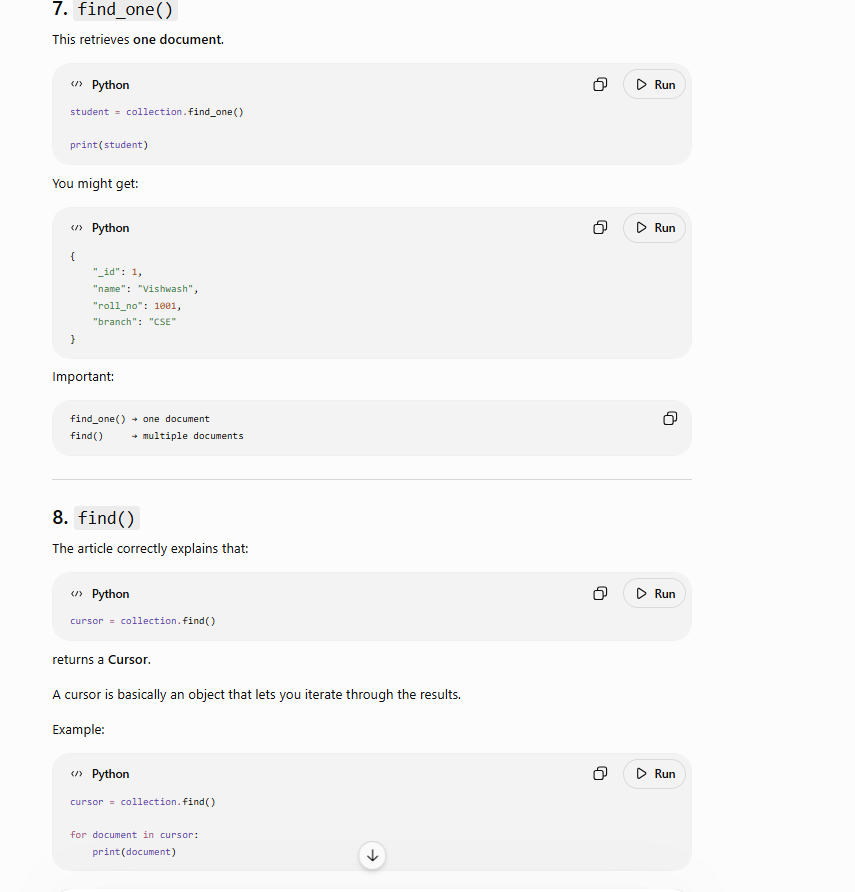

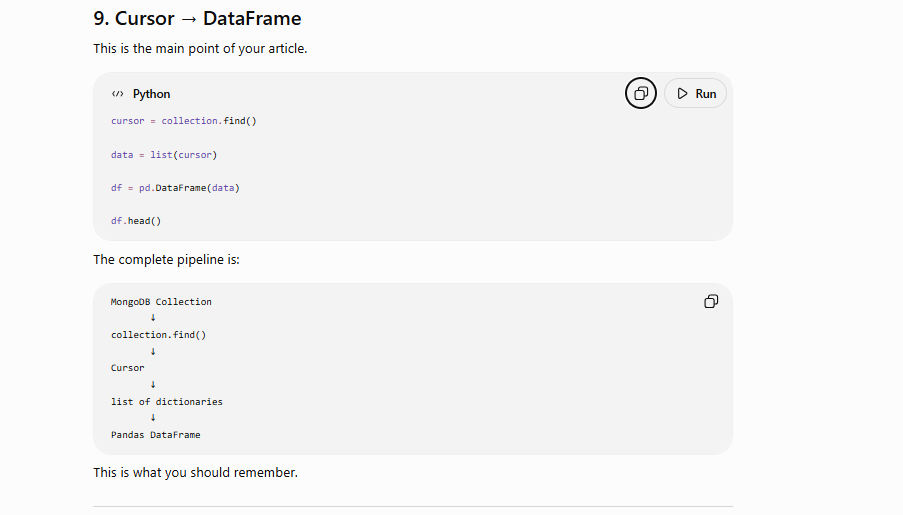

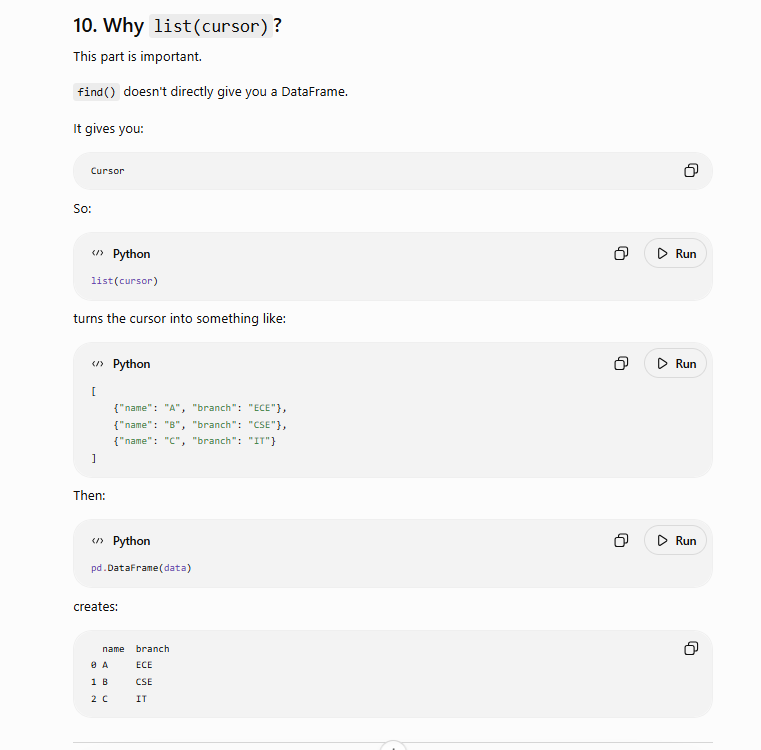

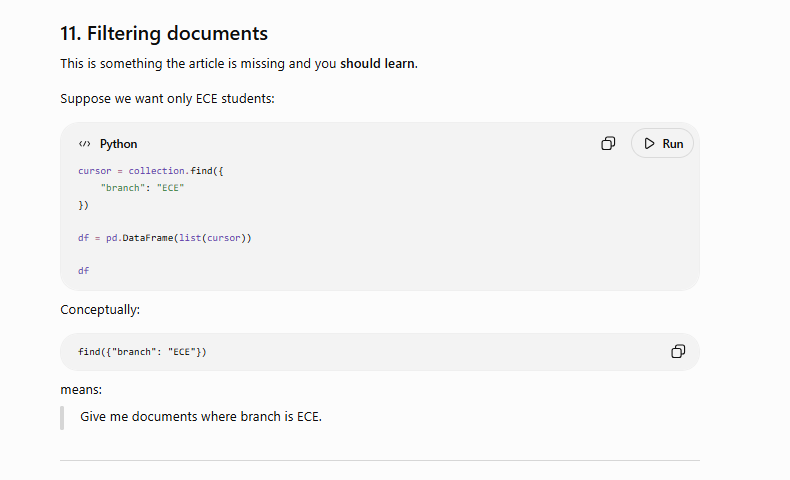

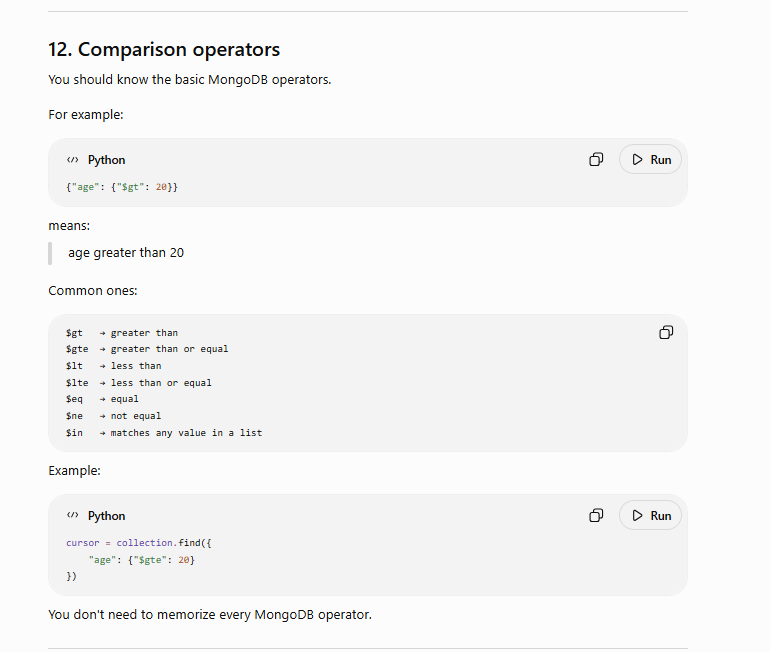

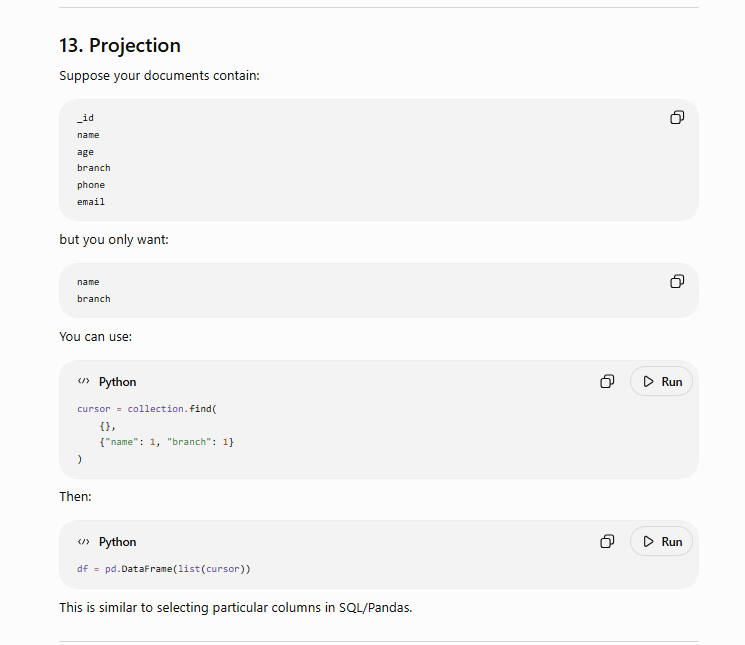

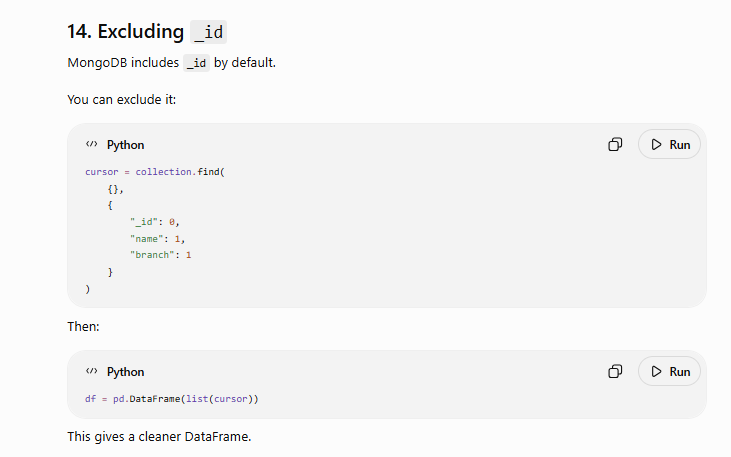

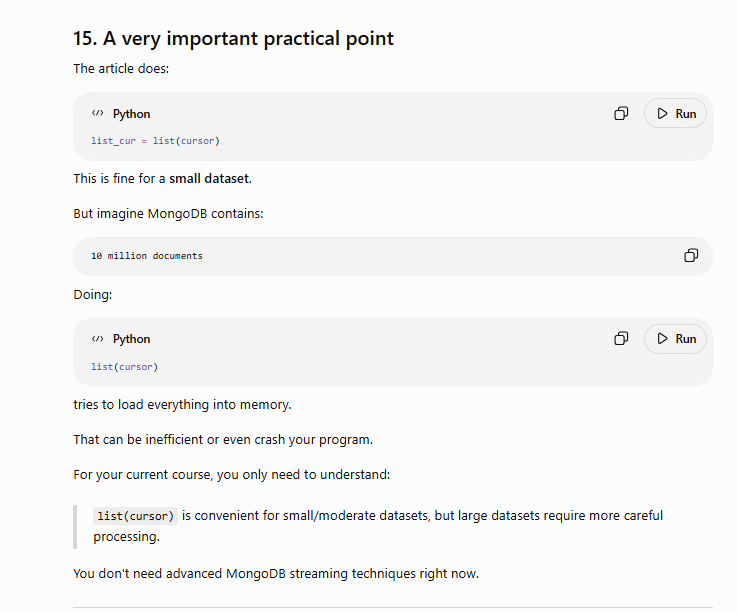

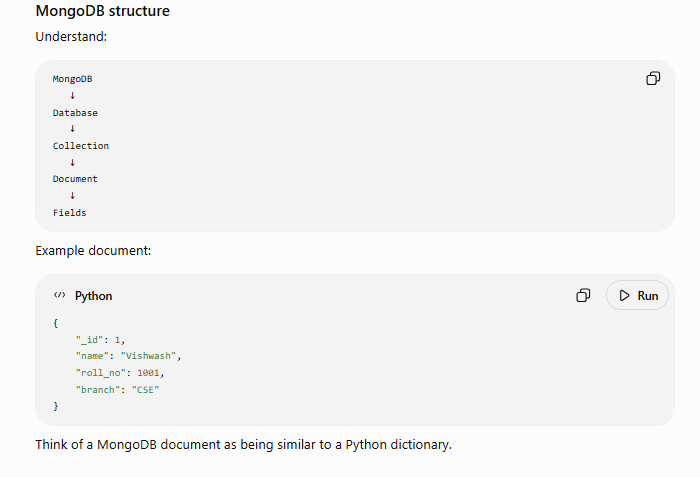

In [181]:
from pymongo import MongoClient
import pandas as pd

In [182]:
client = MongoClient("localhost", 27017)

In [183]:
client = MongoClient("YOUR_CONNECTION_STRING")

In [184]:

db = client["college"]

collection = db["students"]

In [185]:
mydatabase = client.GFG
mycollection = mydatabase.College

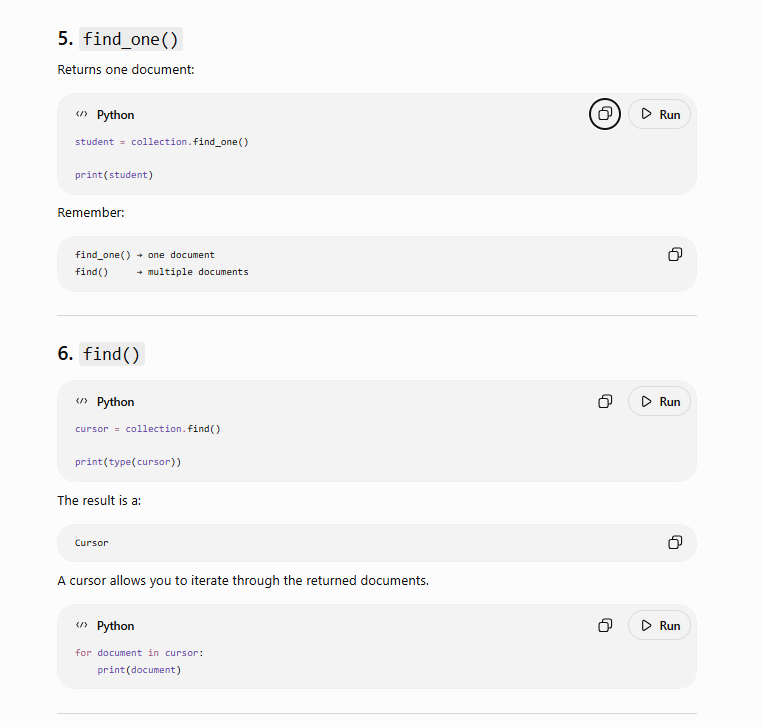

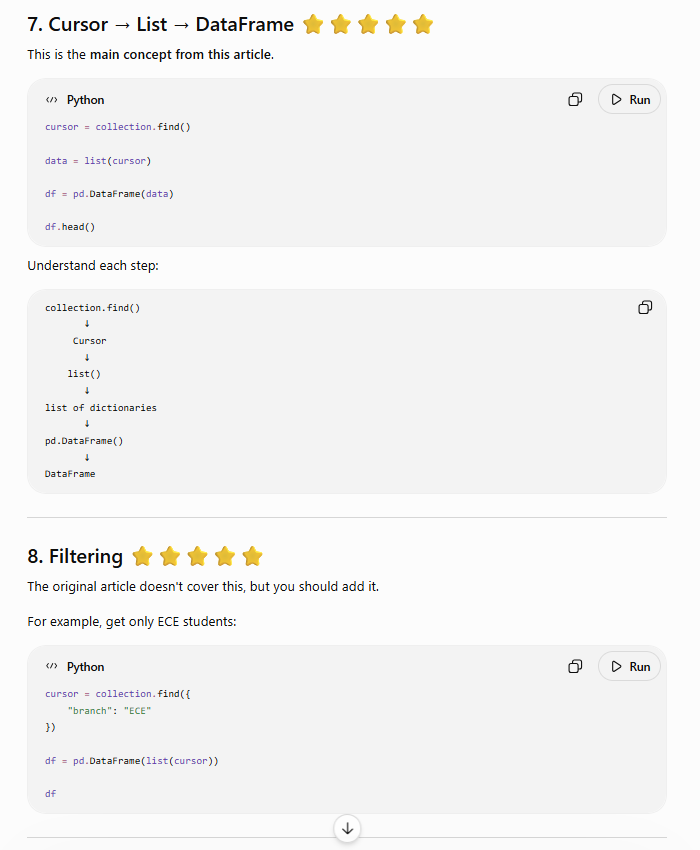

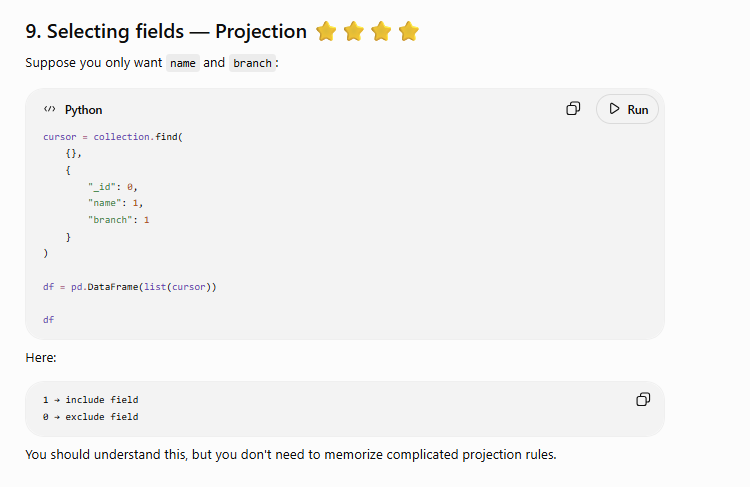